# Recap and Motivation

Github link: https://github.com/yyahsi/food_price_forecast/tree/main

This project focuses on forecasting short term global food prices using regression models. The dataset from P1 contains six months of food price data for 14 items across 122 countries, also economic indicators such as exchange rates, inflation, and FAO index values. The main target variable is Price_USD, which represents the food price in U.S. dollars for a specific city and month. Based on the analysis in P1, food prices showed strong relationship between months, so the models in this part were designed to predict future prices using previous monthly price information. To make the forecasting more realistic and avoid data leakage, the dataset was split by unseen cities during training and testing.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
) 
# importing cleaned data
df = pd.read_csv("cleaned_food_prices.csv")

# Feature Engineering

The Month column was converted into a time index to preserve the order of the six-month period. One-hot encoding was applied to categorical variables such as Continent and Item_Category so they could be used in regression models. Average values of exchange rate, inflation, FAO index, and population from the first three months were also created to represent economic conditions. In the polynomial regression section, polynomial and interaction features were generated to capture nonlinear relationships between variables. All applied within the regression algorithms below.

# Train/Validation/Test Split

Cross-validation was used during Ridge and Lasso regularization to automatically determine optimal regularization strength, while the other regression models were evaluated using a city-based train-test split (80 to 20) to prevent data leakage and try forecasting on unseen locations.

# Multi-Output Forecasting Baseline Model
 Use first 3 months -> predict next 3 months - 
 Split by unseen cities

The model used one observed month to predict the following three months. Despite being a simpler setup, the model still achieved very high accuracy because food prices showed strong contiunity over short periods. 

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

df = pd.read_csv("cleaned_food_prices.csv")

# Convert Month to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Sort properly
df = df.sort_values(
    ["Country", "City", "Item", "Month"]
).reset_index(drop=True)

# Create month index

month_order = {
    month: idx + 1
    for idx, month in enumerate(sorted(df["Month"].unique()))
}

df["Time_Index"] = df["Month"].map(month_order)

# months into columns

pivot_df = df.pivot_table(
    index=["Country", "City", "Item"],
    columns="Time_Index",
    values="Price_USD"
).reset_index()

pivot_df.columns = [
    "Country",
    "City",
    "Item",
    "Month_1",
    "Month_2",
    "Month_3",
    "Month_4",
    "Month_5",
    "Month_6"
]

pivot_df = pivot_df.dropna().reset_index(drop=True)

rows = []

for _, row in pivot_df.iterrows():

    rows.append({
        "Country": row["Country"],
        "City": row["City"],
        "Item": row["Item"],

        "Input_Month": row["Month_1"],

        "Target_1": row["Month_2"],
        "Target_2": row["Month_3"],
        "Target_3": row["Month_4"]
    })

    rows.append({
        "Country": row["Country"],
        "City": row["City"],
        "Item": row["Item"],

        "Input_Month": row["Month_2"],

        "Target_1": row["Month_3"],
        "Target_2": row["Month_4"],
        "Target_3": row["Month_5"]
    })

    rows.append({
        "Country": row["Country"],
        "City": row["City"],
        "Item": row["Item"],

        "Input_Month": row["Month_3"],

        "Target_1": row["Month_4"],
        "Target_2": row["Month_5"],
        "Target_3": row["Month_6"]
    })

baseline_df = pd.DataFrame(rows)

# Split by unseen cities

cities = baseline_df["City"].astype(str).unique().tolist()

train_cities, test_cities = train_test_split(
    cities,
    test_size=0.2,
    random_state=42
)

train_df = baseline_df[
    baseline_df["City"].astype(str).isin(train_cities)
]

test_df = baseline_df[
    baseline_df["City"].astype(str).isin(test_cities)
]

# Features and targets

X_train = train_df[["Input_Month"]]

y_train = train_df[[
    "Target_1",
    "Target_2",
    "Target_3"
]]

X_test = test_df[["Input_Month"]]

y_test = test_df[[
    "Target_1",
    "Target_2",
    "Target_3"
]]

# Scale

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model

baseline_model = LinearRegression()

baseline_model.fit(
    X_train_scaled,
    y_train
)

# Predict

y_train_pred = baseline_model.predict(X_train_scaled)
y_test_pred = baseline_model.predict(X_test_scaled)

# Metrics

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

print("=== Sliding Window Baseline Regression ===")

print("Train R²:", train_r2)
print("Test R²:", test_r2)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

=== Sliding Window Baseline Regression ===
Train R²: 0.9984373237253328
Test R²: 0.998419265811508
Train RMSE: 0.21934874917813188
Test RMSE: 0.1803411712414486
Train MAE: 0.13553569718244698
Test MAE: 0.11564336675437518


# Multiple Linear Regression
First 3 Months -> Predict Next 3 Months -
Added Macroeconomic + Context Features

The multiple linear regression model slightly improved performance  by adding macroeconomic and contextual variables such as exchange rate, inflation, FAO index, continent, and item category. 

=== Multiple Linear Regression ===
Train R²: 0.9994473124499407
Test R²: 0.9994502992591117
Train RMSE: 0.1309840260690572
Test RMSE: 0.10708662357116529
Train MAE: 0.07024930968668489
Test MAE: 0.05961481243215697


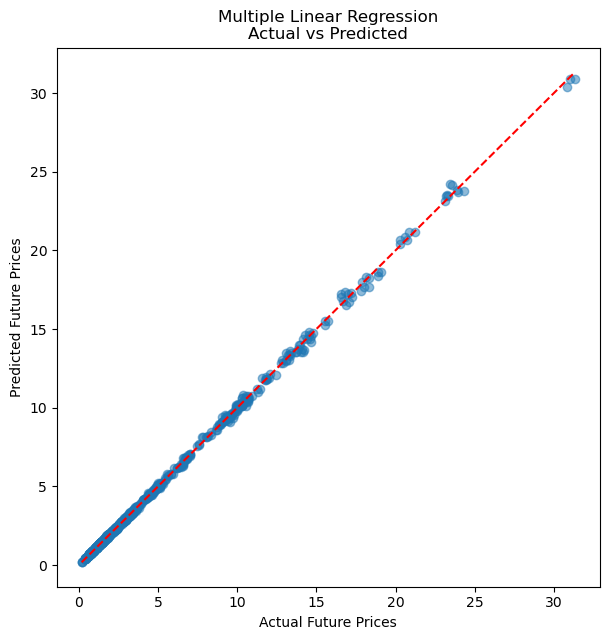

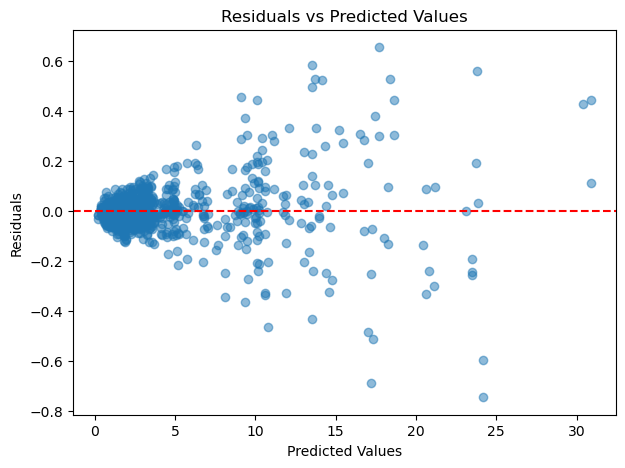

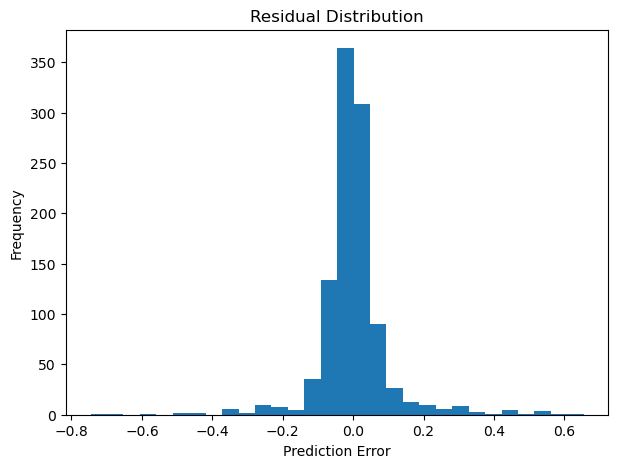

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

df = pd.read_csv("cleaned_food_prices.csv")

# Convert month to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Sort properly
df = df.sort_values(
    ["Country", "City", "Item", "Month"]
).reset_index(drop=True)

month_order = {
    month: idx + 1
    for idx, month in enumerate(sorted(df["Month"].unique()))
}

df["Time_Index"] = df["Month"].map(month_order)

# pivot table

price_pivot = df.pivot_table(
    index=["Country", "City", "Item", "Item_Category", "Continent"],
    columns="Time_Index",
    values="Price_USD"
).reset_index()

price_pivot.columns = [
    "Country",
    "City",
    "Item",
    "Item_Category",
    "Continent",
    "Month_1",
    "Month_2",
    "Month_3",
    "Month_4",
    "Month_5",
    "Month_6"
]

# macroeconomic values integrating
macro_df = (
    df[df["Time_Index"] <= 3]
    .groupby(
        ["Country", "City", "Item"]
    )
    .agg({
        "Exchange_Rate": "mean",
        "YoY_Inflation_Estimate_Pct": "mean",
        "FAO_Index_Value": "mean",
        "Population_Estimate": "mean"
    })
    .reset_index()
)

# Rename columns
macro_df = macro_df.rename(columns={
    "Exchange_Rate": "Avg_Exchange_Rate",
    "YoY_Inflation_Estimate_Pct": "Avg_Inflation",
    "FAO_Index_Value": "Avg_FAO_Index",
    "Population_Estimate": "Avg_Population"
})

# Merge datasets

model_df = pd.merge(
    price_pivot,
    macro_df,
    on=["Country", "City", "Item"],
    how="inner"
)

# Remove incomplete rows
model_df = model_df.dropna().reset_index(drop=True)

# Split by unseen cities

cities = model_df["City"].astype(str).unique().tolist()

train_cities, test_cities = train_test_split(
    cities,
    test_size=0.2,
    random_state=42
)

train_df = model_df[
    model_df["City"].astype(str).isin(train_cities)
]

test_df = model_df[
    model_df["City"].astype(str).isin(test_cities)
]

# Features and targets

feature_cols = [
    "Month_1",
    "Month_2",
    "Month_3",
    "Avg_Exchange_Rate",
    "Avg_Inflation",
    "Avg_FAO_Index",
    "Avg_Population",
    "Continent",
    "Item_Category"
]

target_cols = [
    "Month_4",
    "Month_5",
    "Month_6"
]

X_train = train_df[feature_cols]
y_train = train_df[target_cols]

X_test = test_df[feature_cols]
y_test = test_df[target_cols]

# Feature groups

numerical_features = [
    "Month_1",
    "Month_2",
    "Month_3",
    "Avg_Exchange_Rate",
    "Avg_Inflation",
    "Avg_FAO_Index",
    "Avg_Population"
]

categorical_features = [
    "Continent",
    "Item_Category"
]

# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Pipeline

multiple_lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train model

multiple_lr_model.fit(X_train, y_train)

# Predict

y_train_pred = multiple_lr_model.predict(X_train)
y_test_pred = multiple_lr_model.predict(X_test)

# Metrics

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

print("=== Multiple Linear Regression ===")

print("Train R²:", train_r2)
print("Test R²:", test_r2)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

# Actual vs Predicted plot

plt.figure(figsize=(7,7))

plt.scatter(
    y_test.values.flatten(),
    y_test_pred.flatten(),
    alpha=0.5
)

plt.plot(
    [
        y_test.values.min(),
        y_test.values.max()
    ],
    [
        y_test.values.min(),
        y_test.values.max()
    ],
    "r--"
)

plt.xlabel("Actual Future Prices")
plt.ylabel("Predicted Future Prices")

plt.title(
    "Multiple Linear Regression\nActual vs Predicted"
)

plt.show()

# Residual plot

residuals = (
    y_test.values.flatten()
    - y_test_pred.flatten()
)

plt.figure(figsize=(7,5))

plt.scatter(
    y_test_pred.flatten(),
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(
    "Residuals vs Predicted Values"
)

plt.show()

# Residual histogram

plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

# Polynomial Regression
First 3 months -> predict next 3 months

Degree 2 polynomial regression slightly improved the training performance by capturing nonlinear relationships and feature interactions, whereas degree 3 overfitted the training data.


=== Polynomial Regression Degree 2 ===
Train R²: 0.999608433253177
Test R²: 0.999346160993405
Train RMSE: 0.11025691390175092
Test RMSE: 0.11675099853499189
Train MAE: 0.061951761694640284
Test MAE: 0.0669191977930524

=== Polynomial Regression Degree 3 ===
Train R²: 0.9998343539253195
Test R²: 0.9835041117177784
Train RMSE: 0.07171797644954699
Test RMSE: 0.5828884236748008
Train MAE: 0.039660472940168286
Test MAE: 0.23906237974488911


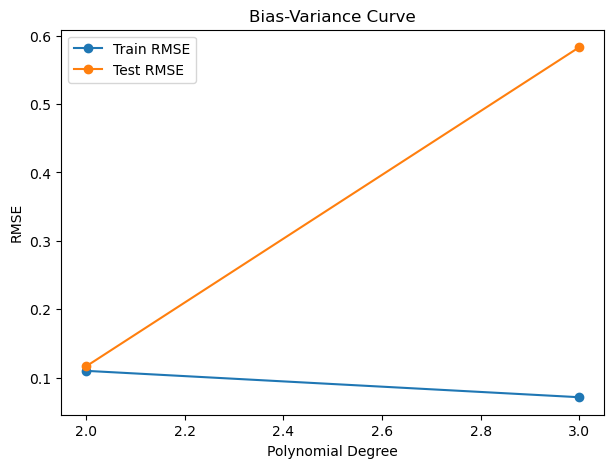


Best Polynomial Degree: 2


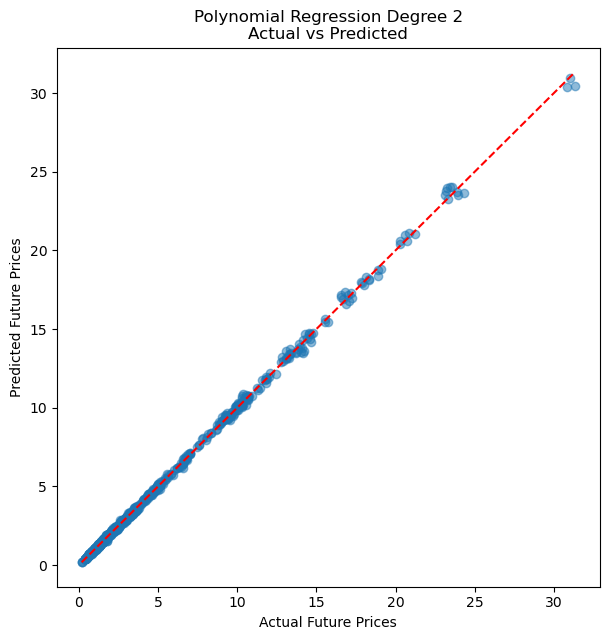

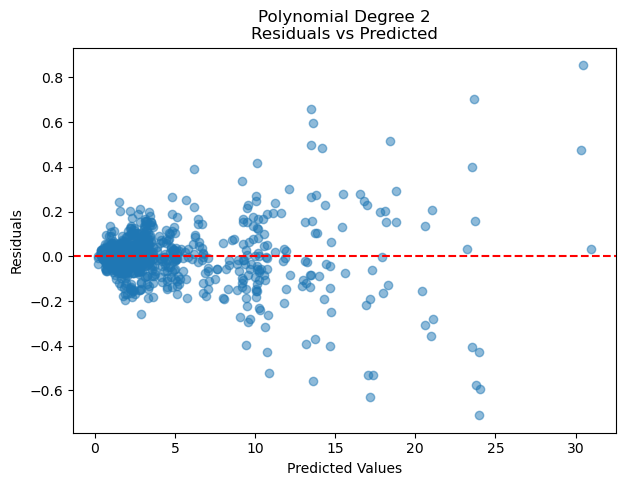

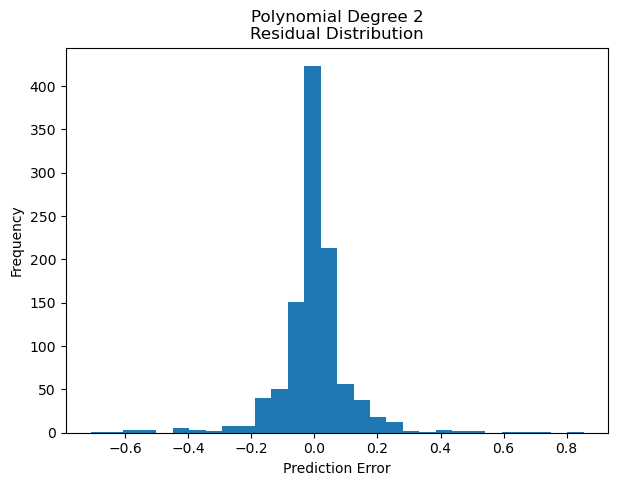

In [63]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

poly_results = []

# Try degree 2 and degree 3
for degree in [2, 3]:

    # Polynomial regression pipeline
    poly_model = Pipeline([
        ("preprocessor", preprocessor),

        ("poly", PolynomialFeatures(
            degree=degree,
            include_bias=False
        )),

        ("model", LinearRegression())
    ])

    # Train model
    poly_model.fit(X_train, y_train)

    # Predictions
    y_train_pred = poly_model.predict(X_train)
    y_test_pred = poly_model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, y_train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, y_test_pred)
    )

    train_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    # Store results
    poly_results.append({
        "Degree": degree,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "Train_MAE": train_mae,
        "Test_MAE": test_mae
    })

    # Print results
    print(f"\n=== Polynomial Regression Degree {degree} ===")

    print("Train R²:", train_r2)
    print("Test R²:", test_r2)

    print("Train RMSE:", train_rmse)
    print("Test RMSE:", test_rmse)

    print("Train MAE:", train_mae)
    print("Test MAE:", test_mae)

# Bias-Variance Curve

degrees = [r["Degree"] for r in poly_results]

train_errors = [r["Train_RMSE"] for r in poly_results]
test_errors = [r["Test_RMSE"] for r in poly_results]

plt.figure(figsize=(7,5))

plt.plot(
    degrees,
    train_errors,
    marker='o',
    label='Train RMSE'
)

plt.plot(
    degrees,
    test_errors,
    marker='o',
    label='Test RMSE'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")

plt.title("Bias-Variance Curve")

plt.legend()

plt.show()

# Actual vs Predicted (Best Degree)

best_degree = min(
    poly_results,
    key=lambda x: x["Test_RMSE"]
)["Degree"]

print(f"\nBest Polynomial Degree: {best_degree}")

# Retrain best model
best_poly_model = Pipeline([
    ("preprocessor", preprocessor),

    ("poly", PolynomialFeatures(
        degree=best_degree,
        include_bias=False
    )),

    ("model", LinearRegression())
])

best_poly_model.fit(X_train, y_train)

y_test_pred_best = best_poly_model.predict(X_test)

# Plot
plt.figure(figsize=(7,7))

plt.scatter(
    y_test.values.flatten(),
    y_test_pred_best.flatten(),
    alpha=0.5
)

plt.plot(
    [
        y_test.values.min(),
        y_test.values.max()
    ],
    [
        y_test.values.min(),
        y_test.values.max()
    ],
    "r--"
)

plt.xlabel("Actual Future Prices")
plt.ylabel("Predicted Future Prices")

plt.title(
    f"Polynomial Regression Degree {best_degree}\nActual vs Predicted"
)

plt.show()

# Residual Analysis

residuals = (
    y_test.values.flatten()
    - y_test_pred_best.flatten()
)

# Residuals vs predicted
plt.figure(figsize=(7,5))

plt.scatter(
    y_test_pred_best.flatten(),
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(
    f"Polynomial Degree {best_degree}\nResiduals vs Predicted"
)

plt.show()

# Residual histogram
plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title(
    f"Polynomial Degree {best_degree}\nResidual Distribution"
)

plt.show()

# Regularization
Ridge and Lasso Regression:
First 3 months -> predict next 3 months

Ridge regression used regularization to stabilize the regression coefficients and reduce sensitivity to feature correlations, though we received very similar results with multiple linear regression

Lasso on the other hand simplified the model by removing some coefficients, and even if by small differences it achieved the best performance amongst other models.

=== Ridge Regression ===
Best Alpha: 2.976351441631316
Train R²: 0.9994420741781281
Test R²: 0.9994426006978618
Train RMSE: 0.13160193001460804
Test RMSE: 0.10783106433297175
Train MAE: 0.07118985490890835
Test MAE: 0.06007189087179867

=== Lasso Regression ===
Best Alpha: 0.001623776739188721
Train R²: 0.9994422906010362
Test R²: 0.9994626606307159
Train RMSE: 0.13158021817155396
Test RMSE: 0.10587785294447549
Train MAE: 0.07007345826393245
Test MAE: 0.0583365476479242

Zeroed-out coefficients: 21
Total coefficients: 60


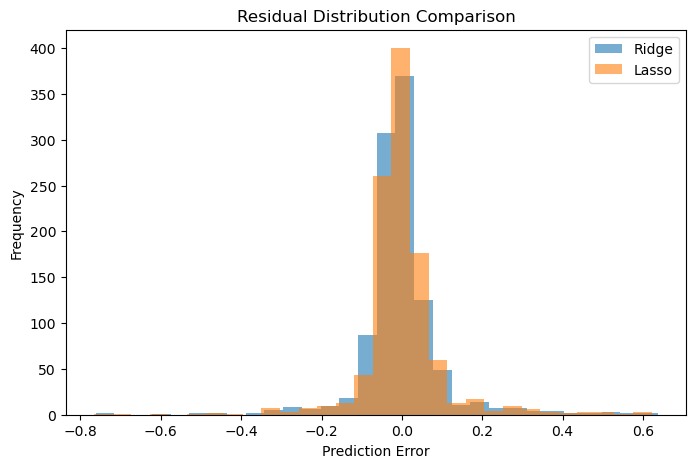

In [64]:
from sklearn.linear_model import RidgeCV, MultiTaskLassoCV
from sklearn.pipeline import Pipeline

# RIDGE REGRESSION

ridge_model = Pipeline([
    ("preprocessor", preprocessor),

    ("model", RidgeCV(
        alphas=np.logspace(-3, 3, 20)
    ))
])

# Train
ridge_model.fit(X_train, y_train)

# Predict
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

# Metrics
ridge_train_r2 = r2_score(
    y_train,
    y_train_pred_ridge
)

ridge_test_r2 = r2_score(
    y_test,
    y_test_pred_ridge
)

ridge_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_ridge
    )
)

ridge_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_ridge
    )
)

ridge_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_ridge
)

ridge_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_ridge
)

print("=== Ridge Regression ===")

print("Best Alpha:",
      ridge_model.named_steps["model"].alpha_)

print("Train R²:", ridge_train_r2)
print("Test R²:", ridge_test_r2)

print("Train RMSE:", ridge_train_rmse)
print("Test RMSE:", ridge_test_rmse)

print("Train MAE:", ridge_train_mae)
print("Test MAE:", ridge_test_mae)

# LASSO REGRESSION
# Multi-output version

lasso_model = Pipeline([
    ("preprocessor", preprocessor),

    ("model", MultiTaskLassoCV(
        alphas=np.logspace(-3, 1, 20),
        cv=5,
        max_iter=20000
    ))
])

# Train
lasso_model.fit(X_train, y_train)

# Predict
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

# Metrics
lasso_train_r2 = r2_score(
    y_train,
    y_train_pred_lasso
)

lasso_test_r2 = r2_score(
    y_test,
    y_test_pred_lasso
)

lasso_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_lasso
    )
)

lasso_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_lasso
    )
)

lasso_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_lasso
)

lasso_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_lasso
)

print("\n=== Lasso Regression ===")

print("Best Alpha:",
      lasso_model.named_steps["model"].alpha_)

print("Train R²:", lasso_train_r2)
print("Test R²:", lasso_test_r2)

print("Train RMSE:", lasso_train_rmse)
print("Test RMSE:", lasso_test_rmse)

print("Train MAE:", lasso_train_mae)
print("Test MAE:", lasso_test_mae)

# Count zeroed-out coefficients

lasso_coefficients = (
    lasso_model.named_steps["model"].coef_
)

zeroed_coefficients = np.sum(
    lasso_coefficients == 0
)

total_coefficients = lasso_coefficients.size

print("\nZeroed-out coefficients:",
      zeroed_coefficients)

print("Total coefficients:",
      total_coefficients)

# Residual comparison plot

ridge_residuals = (
    y_test.values.flatten()
    - y_test_pred_ridge.flatten()
)

lasso_residuals = (
    y_test.values.flatten()
    - y_test_pred_lasso.flatten()
)

plt.figure(figsize=(8,5))

plt.hist(
    ridge_residuals,
    bins=30,
    alpha=0.6,
    label="Ridge"
)

plt.hist(
    lasso_residuals,
    bins=30,
    alpha=0.6,
    label="Lasso"
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Residual Distribution Comparison")

plt.legend()

plt.show()

# Model Comparison

Final Model Comparison Table


In [ ]:
comparison_df = pd.DataFrame({

    "Model": [
        "Baseline Regression",
        "Multiple Linear Regression",
        "Polynomial Regression (Degree 2)",
        "Polynomial Regression (Degree 3)",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "Train R²": [
        0.9984373237253328,
        0.9994473124499407,
        0.999608433253177,
        0.9998343539253195,
        0.9994420741781281,
        0.9994422906010362
    ],

    "Test R²": [
        0.998419265811508,
        0.9994502992591117,
        0.999346160993405,
        0.9835041117177784,
        0.9994426006978618,
        0.9994626606307159
    ],

    "Train RMSE": [
        0.21934874917813188,
        0.1309840260690572,
        0.11025691390175092,
        0.07171797644954699,
        0.13160193001460804,
        0.13158021817155396
    ],

    "Test RMSE": [
        0.1803411712414486,
        0.10708662357116529,
        0.11675099853499189,
        0.5828884236748008,
        0.10783106433297175,
        0.10587785294447549
    ],

    "Train MAE": [
        0.13553569718244698,
        0.07024930968668489,
        0.061951761694640284,
        0.039660472940168286,
        0.07118985490890835,
        0.07007345826393245
    ],

    "Test MAE": [
        0.11564336675437518,
        0.05961481243215697,
        0.0669191977930524,
        0.23906237974488911,
        0.06007189087179867,
        0.0583365476479242
    ]
})

# Round for cleaner display
comparison_df = comparison_df.round(6)

# Display final table
print("\n=== Final Model Comparison Table ===\n")

print(comparison_df.to_string(index=False))


=== Final Model Comparison Table ===

                           Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE
             Baseline Regression  0.998437 0.998419    0.219349   0.180341   0.135536  0.115643
      Multiple Linear Regression  0.999447 0.999450    0.130984   0.107087   0.070249  0.059615
Polynomial Regression (Degree 2)  0.999608 0.999346    0.110257   0.116751   0.061952  0.066919
Polynomial Regression (Degree 3)  0.999834 0.983504    0.071718   0.582888   0.039660  0.239062
                Ridge Regression  0.999442 0.999443    0.131602   0.107831   0.071190  0.060072
                Lasso Regression  0.999442 0.999463    0.131580   0.105878   0.070073  0.058337


# Interpretation and Reflection

Overall, we have seen short term food prices are extremely predictable simply using time series price data. Worst performing one, the baseline model only using historical price data had above 0.998 values for R², and around 0.2 RMSE values. This model retained such high peformance using only a months data and predicting the next three unlike the other approaches. Such results make sense when we consider food prices are mostly related to previous months prices. Even though some fluctuations by seasonal, global economic changes exist and our initial approach was to create a model that incorporated geographic and ecomomic differences, previous month's prices highly overshadowed our aim in finding a good model.

The dilemma we had is either we dont use item prices at all and try finding a good model by other data, however that was not going to be nearly sufficient because our data was not big enough to capture it without overfitting to those values like region, then we would still have low test accuracy. Instead of that approach we used the previous price data, however tried to make our problem harder by giving first three months and predicting the next three instead of a simple month calculation. From P1 graphs and plots analysis we have observed foods has certain trends they follow, by months, food types, regions. However we believe our algorithms havent been able to capture those coefficients well, since the problem we have had was easily solvable through normal means.

Analysis for the regression algorithms:

Multiple linear regression improved our algorithm by including other variables, however previous economic data showed much greater relation than geographic data, therefore only slight improvements were observed. This simple algorithm remains the second best performing one after lasso regularization.

One can expect a polynomial trend in price forecasts, however, even though our training errors were lowered in the process test data were slightly increased in 2nd degree polynomial regression. This change was even more obvious when we applied 3rd degree polynomial, where overfitting was so apparent. Highest test RMSE s and lower R² scores, even if train accuracy increases our model didnt learn, so this is a simple example of overfitting.

Ridge regression didnt improve upon linear regression becuase multiple coefficients and stabilizing them were not an issue in the dataset we had. The best performing one lasso regression removed unnecessary coefficients which suggests some features didnt provide any predictive value to our algorithm beyond price information. This was somewhat observable in the heatmap we had, however we still kept onto those variables but they werent of value.


In the end lasso regression is the most balanced and efficient model among all tested approaches we had.